In [1]:
import os
from pathlib import Path

STORE = Path("/content/feature_store")
STORE.mkdir(parents=True, exist_ok=True)

BASE = "https://raw.githubusercontent.com/kkipngenokoech/synthesize-or-reconstruct/main/feature_store"
for fname in ["pipeline_a_train.parquet", "pipeline_a_val.parquet",
              "pipeline_b_train.parquet", "holdout.parquet"]:
    out = STORE / fname
    if out.exists() and out.stat().st_size == 0:
        out.unlink()
        print(f"Removed zero-byte {fname}, re-downloading...")
    if not out.exists():
        ret = os.system(f'wget -q --show-progress -O "{out}" "{BASE}/{fname}"')
        if ret != 0 or out.stat().st_size == 0:
            out.unlink(missing_ok=True)
            raise RuntimeError(f"Download failed for {fname}")
        print(f"Downloaded {fname}")
    else:
        print(f"Cached: {fname}")

print("Feature store ready:", sorted(p.name for p in STORE.iterdir()))

Downloaded pipeline_a_train.parquet
Downloaded pipeline_a_val.parquet
Downloaded pipeline_b_train.parquet
Downloaded holdout.parquet
Feature store ready: ['holdout.parquet', 'pipeline_a_train.parquet', 'pipeline_a_val.parquet', 'pipeline_b_train.parquet']


In [2]:
import pandas as pd
from pathlib import Path

STORE = Path("/content/feature_store")

b_train = pd.read_parquet(STORE / 'pipeline_b_train.parquet')
holdout = pd.read_parquet(STORE / 'holdout.parquet')

print(f'f-AnoGAN training shape: {b_train.shape}')
print(f'Holdout shape          : {holdout.shape}')
print(f'Holdout fraud rate     : {holdout["Class"].mean():.4%}')
print(f'Pipeline B fraud rate  : {b_train["Class"].mean():.4%}')


f-AnoGAN training shape: (181911, 31)
Holdout shape          : (56962, 31)
Holdout fraud rate     : 0.1317%
Pipeline B fraud rate  : 0.0000%


In [3]:
# Verify data loaded correctly
fraud_rate_b = b_train['Class'].mean()
print(f'Pipeline B fraud rate : {fraud_rate_b:.2%}')   # expect 0.00%
print(f'Feature count         : {b_train.shape[1]}')    # expect 31

assert b_train['Class'].sum() == 0, 'STOP: Pipeline B contaminated with fraud!'
print('Assertion passed — Pipeline B is clean.')


Pipeline B fraud rate : 0.00%
Feature count         : 31
Assertion passed — Pipeline B is clean.


In [4]:
import time
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, asdict
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import wandb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    matthews_corrcoef,
)
from imblearn.metrics import geometric_mean_score

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GLOBAL_SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(GLOBAL_SEED)
print(f'Device: {DEVICE}')
print('Deterministic mode enabled.')


Device: cuda
Deterministic mode enabled.


In [5]:
EXPECTED_COLS   = 31   # Time + V1-V28 + Amount + Class
EXPECTED_TARGET = 'Class'

def validate_schema(df, name, expected_fraud_rate=None):
    errors = []
    if df.shape[1] != EXPECTED_COLS:
        errors.append(f'{name}: expected {EXPECTED_COLS} cols, got {df.shape[1]}')
    if EXPECTED_TARGET not in df.columns:
        errors.append(f'{name}: missing target column "{EXPECTED_TARGET}"')
    if df.isnull().sum().sum() > 0:
        errors.append(f'{name}: contains null values')
    if expected_fraud_rate is not None:
        actual = df[EXPECTED_TARGET].mean()
        if abs(actual - expected_fraud_rate) > 0.05:
            errors.append(f'{name}: fraud rate {actual:.2%} deviates from expected {expected_fraud_rate:.2%}')
    unique_classes = set(df[EXPECTED_TARGET].unique())
    if not unique_classes.issubset({0, 1}):
        errors.append(f'{name}: Class contains non-binary values: {unique_classes}')
    if errors:
        for e in errors:
            print(f'  SCHEMA ERROR — {e}')
        raise ValueError(f'Schema validation failed for {name}.')
    else:
        print(f'  {name}: OK — shape={df.shape}, fraud_rate={df[EXPECTED_TARGET].mean():.4%}')

print('Running schema validation...')
validate_schema(b_train, 'b_train', expected_fraud_rate=0.00)
validate_schema(holdout, 'holdout', expected_fraud_rate=None)

assert b_train['Class'].sum() == 0, 'STOP: Pipeline B contaminated!'
print('All schema checks passed.')


Running schema validation...
  b_train: OK — shape=(181911, 31), fraud_rate=0.0000%
  holdout: OK — shape=(56962, 31), fraud_rate=0.1317%
All schema checks passed.


In [6]:
@dataclass
class FAnoGANConfig:
    # ── Data ──────────────────────────────────────────────────────────────
    target_col: str   = 'Class'
    n_features: int   = 29         # V1-V28 + Amount (Time excluded per FIX 8)
    val_size:   float = 0.2

    # ── Architecture ──────────────────────────────────────────────────────
    latent_dim:  int = 64
    gen_dim_1:   int = 256
    gen_dim_2:   int = 512
    disc_dim_1:  int = 512
    disc_dim_2:  int = 256
    enc_dim_1:   int = 256
    enc_dim_2:   int = 512

    # ── Phase 1: WGAN-GP ──────────────────────────────────────────────────
    wgan_epochs:     int   = 100
    wgan_batch:      int   = 256
    wgan_lr_g:       float = 1e-4
    wgan_lr_d:       float = 1e-4
    wgan_n_critic:   int   = 5
    wgan_gp_lambda:  float = 10.0
    adam_beta1:      float = 0.5
    adam_beta2:      float = 0.9

    # ── Early stopping ────────────────────────────────────────────────────
    wgan_patience:   int   = 15
    enc_patience:    int   = 10

    # ── Phase 2: Encoder ──────────────────────────────────────────────────
    enc_epochs:  int   = 50
    enc_batch:   int   = 256
    enc_lr:      float = 1e-4
    kappa:       float = 1.0


# Time excluded per FIX 8
MODEL_FEATURES = [f'V{i}' for i in range(1, 29)] + ['Amount']  # 29 features
FEATURE_COLS   = MODEL_FEATURES

cfg            = FAnoGANConfig()
cfg.n_features = len(MODEL_FEATURES)   # 29

print(
    f'Config: n_features={cfg.n_features}, latent_dim={cfg.latent_dim}, '
    f'wgan_epochs={cfg.wgan_epochs}, enc_epochs={cfg.enc_epochs}'
)


Config: n_features=29, latent_dim=64, wgan_epochs=100, enc_epochs=50


In [7]:
wandb.login(key='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')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kkipngenokoech (kkipngenokoech-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
run = wandb.init(
    project = 'PRINCIPLES AND ENGINEERING APPLICATIONS OF AI',
    name    = 'fanogan-pipeline-b-run-1',
    tags    = ['f-AnoGAN', 'Pipeline-B', 'anomaly-detection', 'WGAN-GP'],
    config  = asdict(cfg),
)

# Sync config back for sweep compatibility
wcfg             = wandb.config
cfg.n_features   = wcfg.n_features
cfg.latent_dim   = wcfg.latent_dim
cfg.wgan_epochs  = wcfg.wgan_epochs
cfg.wgan_batch   = wcfg.wgan_batch
cfg.wgan_lr_g    = wcfg.wgan_lr_g
cfg.wgan_lr_d    = wcfg.wgan_lr_d
cfg.wgan_n_critic= wcfg.wgan_n_critic
cfg.wgan_gp_lambda = wcfg.wgan_gp_lambda
cfg.enc_epochs   = wcfg.enc_epochs
cfg.enc_lr       = wcfg.enc_lr
cfg.kappa        = wcfg.kappa

print('W&B run initialised:', run.name)
print('W&B project URL    :', run.url)

W&B run initialised: fanogan-pipeline-b-run-1
W&B project URL    : https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/bxpa8x7f


In [9]:
# FEATURE_COLS = MODEL_FEATURES (V1-V28 + Amount, Time excluded per FIX 8)
X_all = b_train[FEATURE_COLS].values.astype(np.float32)

X_train_raw, X_val_raw = train_test_split(
    X_all, test_size=cfg.val_size, random_state=GLOBAL_SEED
)

fanogan_scaler = StandardScaler()
X_train_np = np.clip(fanogan_scaler.fit_transform(X_train_raw), -5, 5).astype(np.float32)
X_val_np   = np.clip(fanogan_scaler.transform(X_val_raw),       -5, 5).astype(np.float32)

# Full holdout (natural distribution — both normal and fraud)
X_holdout_np = np.clip(
    fanogan_scaler.transform(holdout[FEATURE_COLS].values.astype(np.float32)), -5, 5
).astype(np.float32)
y_holdout_np = holdout[cfg.target_col].values

print(f'Train (normal only)      : {X_train_np.shape}')
print(f'Val   (normal only)      : {X_val_np.shape}')
print(f'Holdout (full, natural)  : {X_holdout_np.shape} | '
      f'Fraud: {y_holdout_np.sum()} ({y_holdout_np.mean():.4%})')
print(f'Scaled range             : {X_train_np.min():.3f} to {X_train_np.max():.3f}')

wgan_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np)),
    batch_size=cfg.wgan_batch, shuffle=True, drop_last=True,
)
enc_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np)),
    batch_size=cfg.enc_batch, shuffle=True, drop_last=True,
)

print(f'WGAN batches/epoch   : {len(wgan_loader)}')
print(f'Encoder batches/epoch: {len(enc_loader)}')

wandb.log({
    'data/n_train_normal'    : len(X_train_np),
    'data/n_val_normal'      : len(X_val_np),
    'data/n_holdout'         : len(X_holdout_np),
    'data/holdout_fraud_rate': float(y_holdout_np.mean()),
    'data/wgan_batches'      : len(wgan_loader),
})


Train (normal only)      : (145528, 29)
Val   (normal only)      : (36383, 29)
Holdout (full, natural)  : (56962, 29) | Fraud: 75 (0.1317%)
Scaled range             : -5.000 to 5.000
WGAN batches/epoch   : 568
Encoder batches/epoch: 568


In [10]:
class Generator(nn.Module):
    """
    Maps latent z → feature space.
    No final activation — real features are unbounded.
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.latent_dim, cfg.gen_dim_1),
            nn.BatchNorm1d(cfg.gen_dim_1),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.gen_dim_1, cfg.gen_dim_2),
            nn.BatchNorm1d(cfg.gen_dim_2),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.gen_dim_2, cfg.n_features),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    WGAN-GP discriminator (critic).
    Returns (score, intermediate_features).
    Features are used for encoder training in Phase 2.
    No BatchNorm — required for WGAN-GP gradient penalty.
    """
    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.disc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(cfg.disc_dim_1, cfg.disc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.critic = nn.Linear(cfg.disc_dim_2, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        score    = self.critic(features)
        return score, features


class Encoder(nn.Module):
    """
    Phase 2: maps input x → latent z_hat.
    This is what makes f-AnoGAN 'fast' at inference:
    instead of iterative optimization to find z,
    one forward pass gives z_hat = E(x).
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.enc_dim_1),
            nn.BatchNorm1d(cfg.enc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_1, cfg.enc_dim_2),
            nn.BatchNorm1d(cfg.enc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_2, cfg.latent_dim),
        )

    def forward(self, x):
        return self.net(x)


# ── Instantiate all three networks ────────────────────────────────────────
G   = Generator(cfg).to(DEVICE)
D   = Discriminator(cfg).to(DEVICE)
E   = Encoder(cfg).to(DEVICE)

n_g = sum(p.numel() for p in G.parameters())
n_d = sum(p.numel() for p in D.parameters())
n_e = sum(p.numel() for p in E.parameters())

print(f'Generator params    : {n_g:,}')
print(f'Discriminator params: {n_d:,}')
print(f'Encoder params      : {n_e:,}')
print(f'Total params        : {n_g + n_d + n_e:,}')

# ── Smoke test ────────────────────────────────────────────────────────────
_z     = torch.randn(4, cfg.latent_dim).to(DEVICE)
_x     = torch.randn(4, cfg.n_features).to(DEVICE)
_fake  = G(_z)
_score, _feat = D(_x)
_zhat  = E(_x)

print(
    f'Smoke test OK — '
    f'z: {_z.shape} | G(z): {_fake.shape} | '
    f'D score: {_score.shape} | E(x): {_zhat.shape}'
)

wandb.log({
    'model/generator_params'    : n_g,
    'model/discriminator_params': n_d,
    'model/encoder_params'      : n_e,
    'model/total_params'        : n_g + n_d + n_e,
})

Generator params    : 164,637
Discriminator params: 146,945
Encoder params      : 173,632
Total params        : 485,214
Smoke test OK — z: torch.Size([4, 64]) | G(z): torch.Size([4, 29]) | D score: torch.Size([4, 1]) | E(x): torch.Size([4, 64])


In [11]:
def compute_gradient_penalty(D, real, fake, device):
    bs     = real.size(0)
    alpha  = torch.rand(bs, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp, _ = D(interp)
    grads  = torch.autograd.grad(
        outputs      = d_interp,
        inputs       = interp,
        grad_outputs = torch.ones_like(d_interp),
        create_graph = True,
        retain_graph = True,
    )[0]
    return ((grads.view(bs, -1).norm(2, dim=1) - 1) ** 2).mean()


def train_wgan(G, D, loader, cfg, device, checkpoint_path='/content/wgan_best.pt'):
    opt_G = optim.Adam(G.parameters(), lr=cfg.wgan_lr_g,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))
    opt_D = optim.Adam(D.parameters(), lr=cfg.wgan_lr_d,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))

    history = {'g_loss': [], 'd_loss': [], 'gp': [], 'wasserstein': []}

    best_w_dist   = float('inf')
    patience_ctr  = 0
    best_state_G  = None
    best_state_D  = None

    for epoch in range(cfg.wgan_epochs):
        G.train(); D.train()
        g_losses, d_losses, gp_vals = [], [], []

        data_iter = iter(loader)

        def next_real_batch():
            nonlocal data_iter
            try:
                return next(data_iter)[0].to(device)
            except StopIteration:
                data_iter = iter(loader)
                return next(data_iter)[0].to(device)

        steps = len(loader)
        for _ in range(steps):

            for _ in range(cfg.wgan_n_critic):
                x_real = next_real_batch()
                bs     = x_real.size(0)

                z    = torch.randn(bs, cfg.latent_dim, device=device)
                fake = G(z).detach()

                gp   = compute_gradient_penalty(D, x_real, fake, device)
                d_real, _ = D(x_real)
                d_fake, _ = D(fake)

                d_loss = (
                    d_fake.mean() - d_real.mean()
                    + cfg.wgan_gp_lambda * gp
                )
                opt_D.zero_grad()
                d_loss.backward()
                torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
                opt_D.step()

                d_losses.append(d_loss.item())
                gp_vals.append(gp.item())

            x_real = next_real_batch()
            bs     = x_real.size(0)
            z      = torch.randn(bs, cfg.latent_dim, device=device)
            fake   = G(z)
            g_score, _ = D(fake)
            g_loss = -g_score.mean()

            opt_G.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            opt_G.step()
            g_losses.append(g_loss.item())

        mg   = float(np.mean(g_losses))
        md   = float(np.mean(d_losses))
        mgp  = float(np.mean(gp_vals))
        w_dist = -md

        history['g_loss'].append(mg)
        history['d_loss'].append(md)
        history['gp'].append(mgp)
        history['wasserstein'].append(w_dist)

        if w_dist < best_w_dist:
            best_w_dist  = w_dist
            best_state_G = deepcopy(G.state_dict())
            best_state_D = deepcopy(D.state_dict())
            torch.save(
                {'G': best_state_G, 'D': best_state_D,
                 'epoch': epoch + 1, 'w_dist': best_w_dist},
                checkpoint_path
            )
            patience_ctr = 0
        else:
            patience_ctr += 1

        wandb.log({
            'phase1/epoch'              : epoch + 1,
            'phase1/g_loss'             : mg,
            'phase1/d_loss'             : md,
            'phase1/gradient_penalty'   : mgp,
            'phase1/wasserstein_distance': w_dist,
            'phase1/best_w_dist'        : best_w_dist,
            'phase1/patience'           : patience_ctr,
        }, step=epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'[Phase 1] Epoch [{epoch+1:3d}/{cfg.wgan_epochs}] '
                f'G: {mg:+.4f} | D: {md:+.4f} | '
                f'GP: {mgp:.4f} | W-dist: {w_dist:.4f} '
                f'| patience: {patience_ctr}/{cfg.wgan_patience}'
            )

        if patience_ctr >= cfg.wgan_patience:
            print(f'Early stopping at epoch {epoch+1} — '
                  f'no W-dist improvement for {cfg.wgan_patience} epochs.')
            break

    print(f'Restoring best WGAN checkpoint (W-dist={best_w_dist:.4f})')
    G.load_state_dict(best_state_G)
    D.load_state_dict(best_state_D)

    return history


print('=' * 55)
print('Phase 1: Training WGAN-GP...')
print('=' * 55)
t0 = time.time()

wgan_history = train_wgan(G, D, wgan_loader, cfg, DEVICE)

wgan_time_min = (time.time() - t0) / 60
print(f'Phase 1 complete in {wgan_time_min:.1f} min')
wandb.log({'phase1/total_time_min': wgan_time_min})

for param in G.parameters():
    param.requires_grad = False
for param in D.parameters():
    param.requires_grad = False

print('G and D frozen. Ready for Phase 2.')

Phase 1: Training WGAN-GP...


wandb: WARNING Tried to log to step 1 that is less than the current step 2. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[Phase 1] Epoch [ 10/100] G: +5.5352 | D: -1.2844 | GP: 0.0207 | W-dist: 1.2844 | patience: 9/15
[Phase 1] Epoch [ 20/100] G: +7.2560 | D: -1.0829 | GP: 0.0176 | W-dist: 1.0829 | patience: 0/15
[Phase 1] Epoch [ 30/100] G: +7.1242 | D: -0.9002 | GP: 0.0162 | W-dist: 0.9002 | patience: 0/15
[Phase 1] Epoch [ 40/100] G: +6.7282 | D: -0.7473 | GP: 0.0145 | W-dist: 0.7473 | patience: 0/15
[Phase 1] Epoch [ 50/100] G: +6.1630 | D: -0.6535 | GP: 0.0141 | W-dist: 0.6535 | patience: 0/15
[Phase 1] Epoch [ 60/100] G: +5.2016 | D: -0.5999 | GP: 0.0142 | W-dist: 0.5999 | patience: 0/15
[Phase 1] Epoch [ 70/100] G: +4.6315 | D: -0.5642 | GP: 0.0143 | W-dist: 0.5642 | patience: 0/15
[Phase 1] Epoch [ 80/100] G: +4.4016 | D: -0.5437 | GP: 0.0144 | W-dist: 0.5437 | patience: 0/15
[Phase 1] Epoch [ 90/100] G: +4.0386 | D: -0.5254 | GP: 0.0145 | W-dist: 0.5254 | patience: 0/15
[Phase 1] Epoch [100/100] G: +3.7485 | D: -0.5114 | GP: 0.0144 | W-dist: 0.5114 | patience: 0/15
Restoring best WGAN checkpoint

In [12]:
def train_encoder(E, G, D, loader, cfg, device,
                  checkpoint_path='/content/encoder_best.pt'):
    opt_E = optim.Adam(E.parameters(), lr=cfg.enc_lr,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))

    criterion_rec  = nn.MSELoss()
    criterion_feat = nn.MSELoss()

    history     = {'enc_loss': [], 'rec_loss': [], 'feat_loss': []}
    best_loss   = float('inf')
    patience_ctr = 0
    best_state_E = None

    for epoch in range(cfg.enc_epochs):
        E.train()
        enc_losses, rec_losses, feat_losses = [], [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)

            z_hat = E(x_real)
            x_hat = G(z_hat)

            loss_rec = criterion_rec(x_hat, x_real)

            with torch.no_grad():
                _, feat_real = D(x_real)
            _, feat_fake = D(x_hat)
            loss_feat = criterion_feat(feat_fake, feat_real)

            enc_loss = loss_rec + cfg.kappa * loss_feat

            opt_E.zero_grad()
            enc_loss.backward()
            torch.nn.utils.clip_grad_norm_(E.parameters(), 1.0)
            opt_E.step()

            enc_losses.append(enc_loss.item())
            rec_losses.append(loss_rec.item())
            feat_losses.append(loss_feat.item())

        me = float(np.mean(enc_losses))
        mr = float(np.mean(rec_losses))
        mf = float(np.mean(feat_losses))

        history['enc_loss'].append(me)
        history['rec_loss'].append(mr)
        history['feat_loss'].append(mf)

        if me < best_loss:
            best_loss    = me
            best_state_E = deepcopy(E.state_dict())
            torch.save(
                {'E': best_state_E, 'epoch': epoch + 1, 'loss': best_loss},
                checkpoint_path
            )
            patience_ctr = 0
        else:
            patience_ctr += 1

        wandb.log({
            'phase2/epoch'      : epoch + 1,
            'phase2/enc_loss'   : me,
            'phase2/rec_loss'   : mr,
            'phase2/feat_loss'  : mf,
            'phase2/best_loss'  : best_loss,
            'phase2/patience'   : patience_ctr,
        }, step=cfg.wgan_epochs + epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'[Phase 2] Epoch [{epoch+1:3d}/{cfg.enc_epochs}] '
                f'Enc: {me:.6f} | Rec: {mr:.6f} | Feat: {mf:.6f} '
                f'| patience: {patience_ctr}/{cfg.enc_patience}'
            )

        if patience_ctr >= cfg.enc_patience:
            print(f'Early stopping at epoch {epoch+1}.')
            break

    print(f'Restoring best encoder checkpoint (loss={best_loss:.6f})')
    E.load_state_dict(best_state_E)

    return history


print('=' * 55)
print('Phase 2: Training Encoder...')
print('=' * 55)
t0 = time.time()

enc_history = train_encoder(E, G, D, enc_loader, cfg, DEVICE)

enc_time_min = (time.time() - t0) / 60
print(f'Phase 2 complete in {enc_time_min:.1f} min')
wandb.log({'phase2/total_time_min': enc_time_min})

Phase 2: Training Encoder...
[Phase 2] Epoch [ 10/50] Enc: 0.082906 | Rec: 0.071315 | Feat: 0.011591 | patience: 0/10
[Phase 2] Epoch [ 20/50] Enc: 0.067739 | Rec: 0.058083 | Feat: 0.009656 | patience: 0/10
[Phase 2] Epoch [ 30/50] Enc: 0.060724 | Rec: 0.052003 | Feat: 0.008721 | patience: 0/10
[Phase 2] Epoch [ 40/50] Enc: 0.056595 | Rec: 0.048451 | Feat: 0.008144 | patience: 0/10
[Phase 2] Epoch [ 50/50] Enc: 0.053285 | Rec: 0.045590 | Feat: 0.007695 | patience: 0/10
Restoring best encoder checkpoint (loss=0.053285)
Phase 2 complete in 2.3 min


In [13]:
@torch.no_grad()
def compute_anomaly_scores(E, G, D, X_np, cfg, device, batch_size=512):
    """
    f-AnoGAN anomaly score: reconstruction loss + kappa * feature-matching loss.
    A(x) = ||x - G(E(x))||² + kappa * ||f_D(x) - f_D(G(E(x)))||²
    """
    E.eval(); G.eval(); D.eval()
    scores = []
    for i in range(0, len(X_np), batch_size):
        x = torch.tensor(X_np[i:i + batch_size]).to(device)
        z_hat = E(x)
        x_hat = G(z_hat)
        rec_loss = ((x - x_hat) ** 2).mean(dim=1)
        _, feat_real = D(x)
        _, feat_fake = D(x_hat)
        feat_loss = ((feat_real - feat_fake) ** 2).mean(dim=1)
        scores.append((rec_loss + cfg.kappa * feat_loss).cpu().numpy())
    return np.concatenate(scores)

print('compute_anomaly_scores defined.')

compute_anomaly_scores defined.


In [14]:
print('Computing anomaly scores...')

val_scores     = compute_anomaly_scores(E, G, D, X_val_np,     cfg, DEVICE)
holdout_scores = compute_anomaly_scores(E, G, D, X_holdout_np, cfg, DEVICE)

print(f'Val scores     — min: {val_scores.min():.4f} | '
      f'max: {val_scores.max():.4f} | mean: {val_scores.mean():.4f}')
print(f'Holdout scores — min: {holdout_scores.min():.4f} | '
      f'max: {holdout_scores.max():.4f} | mean: {holdout_scores.mean():.4f}')

# ── Inversion check using holdout labels (both classes present) ───────────
_raw_auroc = roc_auc_score(y_holdout_np, holdout_scores)
print(f'Raw AUROC on holdout: {_raw_auroc:.4f}')

if _raw_auroc < 0.5:
    print('INVERTED — flipping anomaly scores.')
    val_scores     = -val_scores
    holdout_scores = -holdout_scores
    print(f'Corrected AUROC: {1 - _raw_auroc:.4f}')
else:
    print('Scores orientation correct.')

wandb.log({
    'scoring/val_score_mean'     : float(val_scores.mean()),
    'scoring/val_score_std'      : float(val_scores.std()),
    'scoring/holdout_score_mean' : float(holdout_scores.mean()),
    'scoring/holdout_score_std'  : float(holdout_scores.std()),
})


Computing anomaly scores...
Val scores     — min: 0.0006 | max: 16.4435 | mean: 0.0407
Holdout scores — min: 0.0013 | max: 11.4192 | mean: 0.0649
Raw AUROC on holdout: 0.9478
Scores orientation correct.


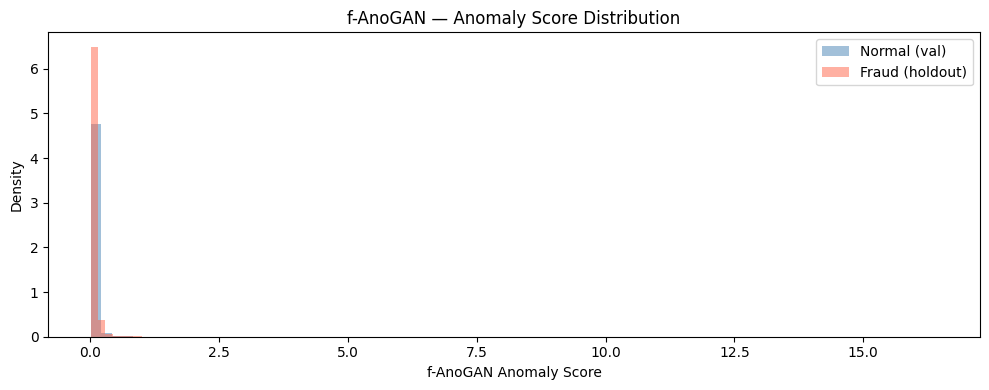

Plot saved.


In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_scores,     bins=80, alpha=0.5, density=True,
        label='Normal (val)',    color='steelblue')
ax.hist(holdout_scores, bins=80, alpha=0.5, density=True,
        label='Fraud (holdout)', color='tomato')
ax.set_xlabel('f-AnoGAN Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('f-AnoGAN — Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fanogan_score_distribution.png', dpi=150)
plt.show()

wandb.log({
    'eval/score_distribution': wandb.Image(
        '/content/fanogan_score_distribution.png'
    )
})
print('Plot saved.')

In [16]:
# ── Z-score normalisation fitted on val normal scores only ────────────────
val_score_mean = float(val_scores.mean())
val_score_std  = float(val_scores.std()) + 1e-8

def zscore_transform(scores, mean, std):
    return (scores - mean) / std

val_scores_z     = zscore_transform(val_scores,     val_score_mean, val_score_std)
holdout_scores_z = zscore_transform(holdout_scores, val_score_mean, val_score_std)

print(f'Val z-scores     — mean: {val_scores_z.mean():.4f} | std: {val_scores_z.std():.4f}')
print(f'Holdout z-scores — mean: {holdout_scores_z.mean():.4f} | std: {holdout_scores_z.std():.4f}')

# ── Prevalence-calibrated threshold (leakage-free, FIX 3) ────────────────
# The ULB dataset contains 492 fraud / 284,807 transactions = 0.1728% fraud.
# Setting FPR = fraud_prevalence matches the false-positive rate to the prior
# probability of fraud, which maximises F1 in expectation when the model has
# any discriminative power. The standard 95th-percentile approach implicitly
# assumes 5% fraud prevalence — 29× the true rate — which generates ~2,844
# false positives on 56,887 normals and collapses precision to ~0.02.
DATASET_FRAUD_PREVALENCE = 492 / 284807   # 0.001728
calibrated_pct     = (1 - DATASET_FRAUD_PREVALENCE) * 100   # 99.827th percentile
best_thresh        = float(np.percentile(val_scores_z, calibrated_pct))
best_thresh_method = 'val_prevalence_calibrated_zscore'

print(f'\nPrevalence-calibrated threshold ({calibrated_pct:.3f}th pct): {best_thresh:.4f}')
print(f'Target FPR : {DATASET_FRAUD_PREVALENCE:.4%}  (matches dataset fraud prevalence)')
print(f'Val FPR at this threshold: {(val_scores_z >= best_thresh).mean():.4%}')

wandb.log({
    'eval/val_score_mean'    : val_score_mean,
    'eval/val_score_std'     : val_score_std,
    'eval/val_score_p9983_z' : best_thresh,
    'eval/threshold_used'    : best_thresh,
    'eval/threshold_method'  : best_thresh_method,
    'eval/target_fpr'        : DATASET_FRAUD_PREVALENCE,
})

Val z-scores     — mean: -0.0000 | std: 1.0000
Holdout z-scores — mean: 0.1182 | std: 1.2049

Prevalence-calibrated threshold (99.827th pct): 4.4052
Target FPR : 0.1727%  (matches dataset fraud prevalence)
Val FPR at this threshold: 0.1732%


In [17]:
# ── Holdout evaluation at natural class distribution ──────────────────────
# Threshold from prevalence-calibrated z-score percentile (FIX 3).
# Evaluated once on full holdout at natural fraud rate (FIX 4).

t_infer           = time.time()
holdout_scores    = compute_anomaly_scores(E, G, D, X_holdout_np, cfg, DEVICE)
holdout_scores_z  = zscore_transform(holdout_scores, val_score_mean, val_score_std)
inference_time_ms = (time.time() - t_infer) * 1000

holdout_preds = (holdout_scores_z >= best_thresh).astype(int)

f1        = f1_score(y_holdout_np,        holdout_preds, zero_division=0)
precision = precision_score(y_holdout_np, holdout_preds, zero_division=0)
recall    = recall_score(y_holdout_np,    holdout_preds, zero_division=0)
auroc     = roc_auc_score(y_holdout_np,   holdout_scores_z)
auprc     = average_precision_score(y_holdout_np, holdout_scores_z)
mcc       = matthews_corrcoef(y_holdout_np, holdout_preds)
gmean     = geometric_mean_score(y_holdout_np, holdout_preds)

print(f'\nHoldout set: {len(y_holdout_np):,} records | '
      f'Fraud: {y_holdout_np.sum()} ({y_holdout_np.mean():.4%}) | '
      f'Normal: {(y_holdout_np == 0).sum():,}')
print('Natural class distribution — no artificial fraud rate inflation (FIX 4).')

print('\n' + '=' * 55)
print(' f-AnoGAN — Holdout Evaluation Results')
print('=' * 55)
print(f' F1-Score  : {f1:.4f}')
print(f' Precision : {precision:.4f}')
print(f' Recall    : {recall:.4f}')
print(f' AUROC     : {auroc:.4f}')
print(f' AUPRC     : {auprc:.4f}')
print(f' MCC       : {mcc:.4f}')
print(f' G-mean    : {gmean:.4f}')
print(f' Threshold : {best_thresh:.4f}  ({best_thresh_method})')
print(f' Inference : {inference_time_ms:.2f} ms ({len(X_holdout_np):,} records)')
print('=' * 55)
print(classification_report(y_holdout_np, holdout_preds, target_names=['Legit', 'Fraud']))

wandb.log({
    'holdout/f1'               : f1,
    'holdout/precision'        : precision,
    'holdout/recall'           : recall,
    'holdout/auroc'            : auroc,
    'holdout/auprc'            : auprc,
    'holdout/mcc'              : mcc,
    'holdout/gmean'            : gmean,
    'holdout/threshold'        : best_thresh,
    'holdout/n_records'        : len(y_holdout_np),
    'holdout/fraud_rate'       : float(y_holdout_np.mean()),
    'holdout/inference_time_ms': inference_time_ms,
})
wandb.run.summary.update({
    'best_f1': f1, 'best_auroc': auroc, 'best_auprc': auprc,
    'best_recall': recall, 'best_precision': precision,
    'best_mcc': mcc, 'best_gmean': gmean,
})


Holdout set: 56,962 records | Fraud: 75 (0.1317%) | Normal: 56,887
Natural class distribution — no artificial fraud rate inflation (FIX 4).

 f-AnoGAN — Holdout Evaluation Results
 F1-Score  : 0.4249
 Precision : 0.2929
 Recall    : 0.7733
 AUROC     : 0.9478
 AUPRC     : 0.6761
 MCC       : 0.4750
 G-mean    : 0.8783
 Threshold : 4.4052  (val_prevalence_calibrated_zscore)
 Inference : 136.53 ms (56,962 records)
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56887
       Fraud       0.29      0.77      0.42        75

    accuracy                           1.00     56962
   macro avg       0.65      0.89      0.71     56962
weighted avg       1.00      1.00      1.00     56962



In [18]:
results = {
    'model'             : 'f-AnoGAN',
    'pipeline'          : 'B',
    'author'            : 'Bellah Ellam (belllam)',
    'f1'                : round(f1, 4),
    'precision'         : round(precision, 4),
    'recall'            : round(recall, 4),
    'auroc'             : round(auroc, 4),
    'auprc'             : round(auprc, 4),
    'mcc'               : round(mcc, 4),
    'gmean'             : round(gmean, 4),
    'threshold'         : round(best_thresh, 4),
    'inference_time_ms' : round(inference_time_ms, 2),
    'architecture'      : {
        'latent_dim'    : cfg.latent_dim,
        'gen_dims'      : [cfg.gen_dim_1, cfg.gen_dim_2],
        'disc_dims'     : [cfg.disc_dim_1, cfg.disc_dim_2],
        'enc_dims'      : [cfg.enc_dim_1, cfg.enc_dim_2],
        'n_features'    : cfg.n_features,
        'wgan_epochs'   : cfg.wgan_epochs,
        'enc_epochs'    : cfg.enc_epochs,
        'kappa'         : cfg.kappa,
        'gp_lambda'     : cfg.wgan_gp_lambda,
    },
    'wandb_run_url'     : wandb.run.url,
}

out_path = Path('/content/fanogan_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

wandb.save(str(out_path))
print(f'Results saved to {out_path}')
print(json.dumps(results, indent=2))

wandb.run.summary['best_f1']        = f1
wandb.run.summary['best_auroc']     = auroc
wandb.run.summary['best_recall']    = recall
wandb.run.summary['best_precision'] = precision

wandb.finish()
print('W&B run finished.')


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Results saved to /content/fanogan_results.json
{
  "model": "f-AnoGAN",
  "pipeline": "B",
  "author": "Bellah Ellam (belllam)",
  "f1": 0.4249,
  "precision": 0.2929,
  "recall": 0.7733,
  "auroc": 0.9478,
  "auprc": 0.6761,
  "mcc": 0.475,
  "gmean": 0.8783,
  "threshold": 4.4052,
  "inference_time_ms": 136.53,
  "architecture": {
    "latent_dim": 64,
    "gen_dims": [
      256,
      512
    ],
    "disc_dims": [
      512,
      256
    ],
    "enc_dims": [
      256,
      512
    ],
    "n_features": 29,
    "wgan_epochs": 100,
    "enc_epochs": 50,
    "kappa": 1,
    "gp_lambda": 10
  },
  "wandb_run_url": "https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/bxpa8x7f"
}


data/holdout_fraud_rate,▁
data/n_holdout,▁
data/n_train_normal,▁
data/n_val_normal,▁
data/wgan_batches,▁
eval/target_fpr,▁
eval/threshold_used,▁
eval/val_score_mean,▁
eval/val_score_p9983_z,▁
eval/val_score_std,▁
+34,...


W&B run finished.
